# Modelling

Since we already handled the data, we move forward to modelling, begin by importing our library, data through processing, and validate the preprocess code

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

%matplotlib inline

In [48]:
from src import preprocess as pre

file_path = "datasets/kc_house_data.csv"
df = pd.read_csv(file_path)
data = pre.preprocess(df)


In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21612 entries, 0 to 21612
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bedrooms           21612 non-null  int64  
 1   bathrooms          21612 non-null  float64
 2   floors             21612 non-null  float64
 3   waterfront         21612 non-null  int64  
 4   view               21612 non-null  int64  
 5   condition          21612 non-null  int64  
 6   grade              21612 non-null  int64  
 7   yr_built           21612 non-null  int64  
 8   log_price          21612 non-null  float64
 9   year               21612 non-null  int32  
 10  month              21612 non-null  int32  
 11  renovated          21612 non-null  int64  
 12  log_sqft_living    21612 non-null  float64
 13  log_sqft_living15  21612 non-null  float64
 14  log_sqft_above     21612 non-null  float64
 15  log_sqft_lot       21612 non-null  float64
 16  log_sqft_lot15     21612 no

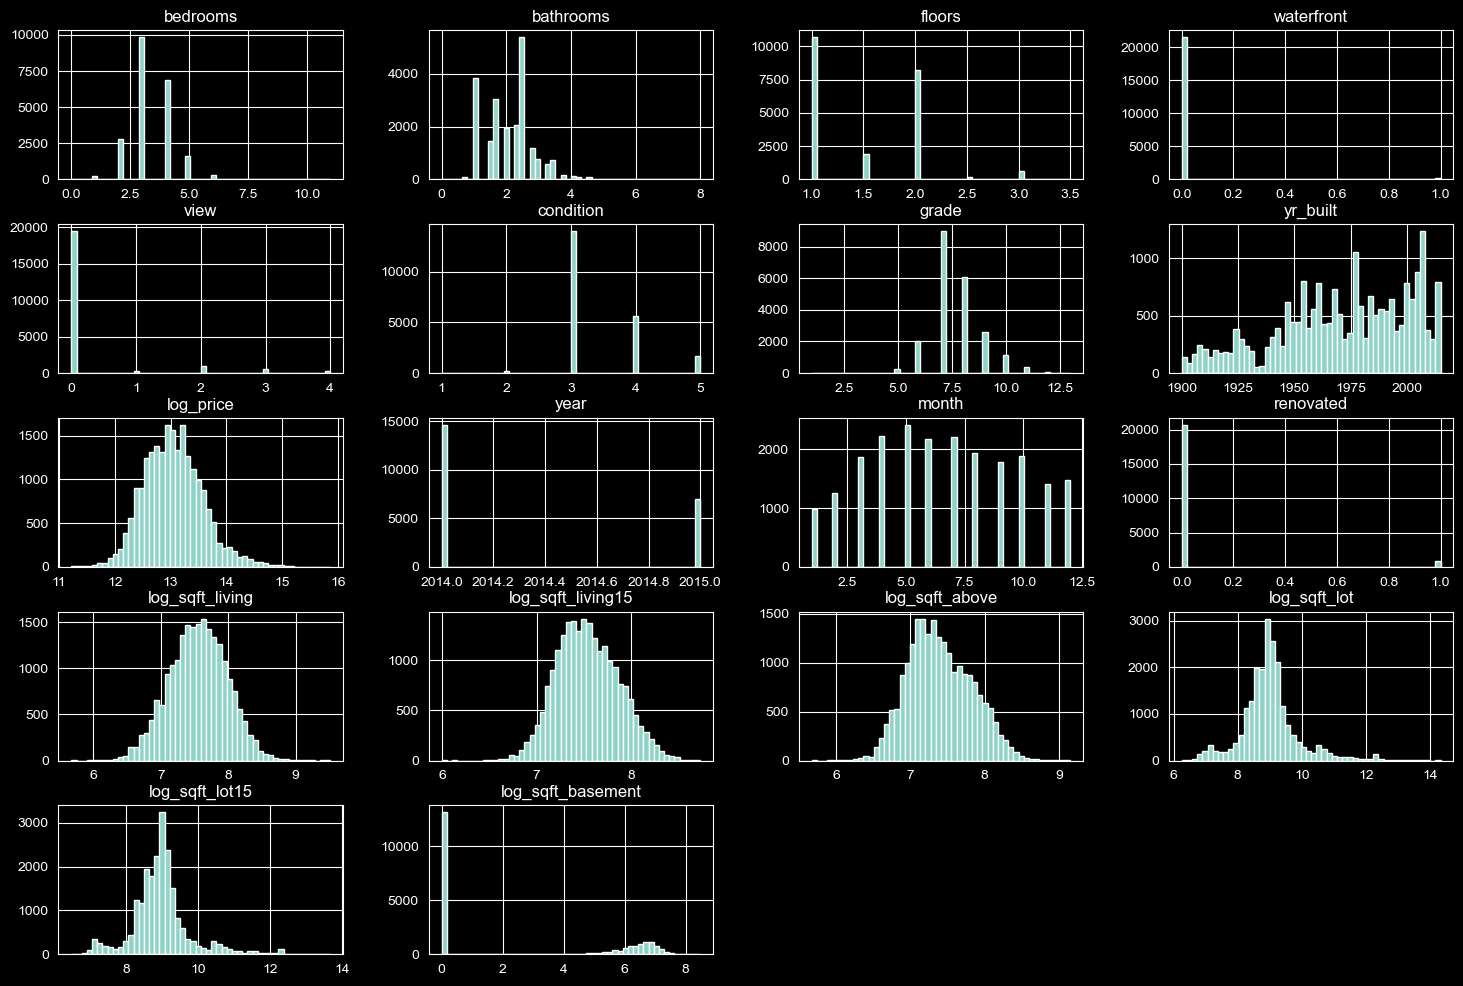

In [50]:
data.hist(figsize=(18,12), bins=50)
plt.show()

Our data had been loaded, and cleaned.

## Splitting


The dataset is divided into training and validation sets to ensure that model performance is evaluated on unseen data. This separation allows for a more reliable assessment of generalization and helps detect overfitting. The model is trained only on the training set, while the validation set is used exclusively for evaluation.

In [51]:
# Code Cell
def train_valid_split(X, y, test_size=0.2, seed=42):
    np.random.seed(seed)
    indices = np.random.permutation(len(X))

    split = int(len(X) * (1 - test_size))
    train_idx, valid_idx = indices[:split], indices[split:]

    return X[train_idx], X[valid_idx], y[train_idx], y[valid_idx]

## Standarization
Feature standardization is applied after splitting the data, using the mean and standard deviation computed from the training set. This ensures that all features are on a comparable scale, preventing those with larger magnitudes from dominating the model. It is especially important for Ridge regression, where regularization depends on feature scale. Applying standardization after the split also avoids data leakage.

In [53]:

def standardize_train(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean) / std, mean, std

def standardize_apply(X, mean, std):
    return (X - mean) / std

## Add Bias Term
We add a column of 1s to represent the intercept (θ₀).

Without this, the model would be forced through the origin (which is unrealistic).Extraction will be needed to distinguish our target data "price" so it wont be exist in the x-axis data

In [54]:
def add_bias(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

## OLS (Ordinary Least Square)
Two models are implemented: Ordinary Least Squares (OLS) as a baseline and Ridge regression as a regularized alternative. OLS provides a simple and interpretable model, while Ridge introduces a penalty on large coefficients to reduce potential overfitting and handle multicollinearity. This comparison allows for evaluating whether regularization provides meaningful improvements.OLS finds θ that minimizes squared error.

In [55]:
def train_ols(X, y):
    X_b = add_bias(X)
    return np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

## Regularization Tuning
Different values of the regularization parameter (λ) are tested to determine the optimal balance between bias and variance. The results show minimal differences across values of λ, indicating that the dataset is already well-conditioned and does not suffer significantly from overfitting. This suggests that regularization has limited impact in this case.

In [56]:
def train_ridge(X, y, lambda_):
    X_b = add_bias(X)

    I = np.eye(X_b.shape[1])
    I[0, 0] = 0

    return np.linalg.pinv(X_b.T @ X_b + lambda_ * I) @ X_b.T @ y

## Prediction Function
We use the learned parameters θ to generate predictions

In [57]:
def predict(X, theta):
    X_b = add_bias(X)
    return X_b @ theta


## Evaluation (MSE)
Model performance is evaluated using Mean Squared Error (MSE), which measures the average squared difference between predicted and actual values. This metric penalizes larger errors more heavily, making it suitable for regression tasks where large deviations are particularly undesirable.

In [58]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

## Polynomial Features

This allows the model to capture non-linear relationships.

Even though the model is linear, transforming features makes it more expressive.

In [59]:
def poly_features(X, degree=2):
    features = [X]
    for d in range(2, degree + 1):
        features.append(X ** d)
    return np.hstack(features)

## Execution

In [60]:
y = data["log_price"].values
X = data.drop(columns=["log_price"]).values

# Split data
x_train, x_valid, y_train, y_valid = train_valid_split(X, y)

# Standardize
x_train, mean, std = standardize_train(x_train)
x_valid = standardize_apply(x_valid, mean, std)

# Optional: polynomial features
x_train = poly_features(x_train, 2)
x_valid = poly_features(x_valid, 2)

# OLS baseline
theta_ols = train_ols(x_train, y_train)
y_pred_ols = predict(x_valid, theta_ols)

print("OLS MSE:", mse(y_valid, y_pred_ols))

# Residuals Check
residuals = y_valid - y_pred_ols
print("Residual mean:", np.mean(residuals))
print("Residual std:", np.std(residuals))

# Ridge tuning
lambdas = [0.01, 0.1, 1, 10]

best_lambda = None
best_mse = float("inf")

for lambda_ in lambdas:
    theta = train_ridge(x_train, y_train, lambda_)
    y_pred = predict(x_valid, theta)

    score = mse(y_valid, y_pred)
    print(f"Ridge λ={lambda_} → MSE:", score)

    if score < best_mse:
        best_mse = score
        best_lambda = lambda_

print("\nBest λ:", best_lambda)
print("Best Ridge MSE:", best_mse)

OLS MSE: 0.0903553758797073
Residual mean: 0.0011567238667778482
Residual std: 0.3005894839637663
Ridge λ=0.01 → MSE: 0.09035537623794211
Ridge λ=0.1 → MSE: 0.09035537946034625
Ridge λ=1 → MSE: 0.09035541556265746
Ridge λ=10 → MSE: 0.09035594688346034

Best λ: 0.01
Best Ridge MSE: 0.09035537623794211


Model performance was evaluated using both Ordinary Least Squares (OLS) and Ridge regression across multiple values of the regularization parameter (λ). The results show that OLS and Ridge produce nearly identical Mean Squared Error (MSE) values, with only negligible differences across all tested λ values. This indicates that the dataset is well-conditioned, with no significant multicollinearity or overfitting issues, and that regularization provides minimal benefit. In other words, the linear model is already stable and sufficiently captures the underlying relationships in the data.

Further validation was conducted through residual analysis, where residuals (the difference between actual and predicted values) were plotted against predicted values. The residuals are centered around zero, with a mean close to zero, indicating that the model is unbiased and does not systematically over- or under-predict. The scatter of residuals appears largely random, with no strong visible patterns, suggesting that the linearity assumption holds and that the model successfully captures the primary structure of the data. Additionally, the variance of residuals is relatively consistent across most prediction ranges, although a slight increase in spread at extreme values suggests minor heteroscedasticity. Overall, these results confirm that the model is well-fitted, and that remaining prediction errors are likely due to subtle non-linear relationships or missing feature interactions rather than issues with the model itself.

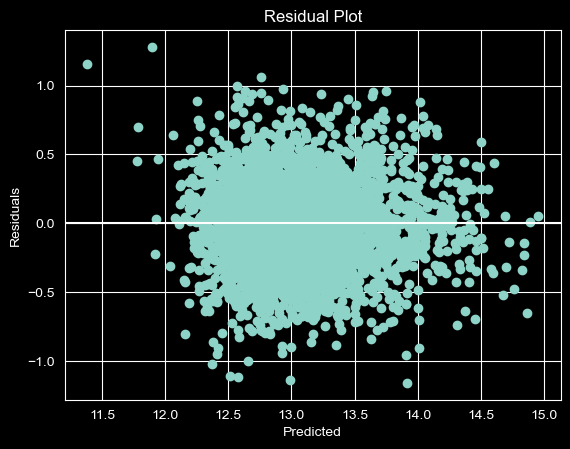

In [61]:
import matplotlib.pyplot as plt

plt.scatter(y_pred_ols, residuals)
plt.axhline(0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()